# Evaluasi Kualitas Hasil Augmentasi.

## TRACK A

In [11]:
import pandas as pd
import os

file_path = "train_balanced_flant5_track_a.csv"

# 2. Cek apakah file ada, lalu load
if os.path.exists(file_path):
    # Load data
    df_hasil_aug = pd.read_csv(file_path)
    print("✅ Berhasil memuat Track A dari CSV.")
    
    # 3. Ambil data yang HANYA hasil augmentasi
    # Filter berdasarkan kolom 'is_augmented'
    aug_only = df_hasil_aug[df_hasil_aug["is_augmented"] == True].copy()
    
    print(f"Jumlah data asli: {len(df_hasil_aug[df_hasil_aug['is_augmented'] == False])}")
    print(f"Jumlah data hasil augmentasi: {len(aug_only)}")
    
    # Tampilkan 3 contoh teratas untuk memastikan teksnya terbaca
    print("\nContoh teks hasil augmentasi:")
    print(aug_only[['text_clean', 'Sentiment']].head(5))
    
else:
    print(f"❌ File tidak ditemukan di: {os.path.abspath(file_path)}")
    print("Pastikan file CSV berada di satu folder yang sama dengan notebook ini.")

✅ Berhasil memuat Track A dari CSV.
Jumlah data asli: 830
Jumlah data hasil augmentasi: 94

Contoh teks hasil augmentasi:
                                           text_clean Sentiment
1   maka ia ke tahun bukau program tetapan program...   neutral
3   tewas dan ds wni dan ds uang meningkat tewas d...   neutral
9   ds berkategori sanksi ada karena berkategori y...  negative
20  Penahanan pada tetapi yang untuk mengawai djan...  negative
22  komunikasi aktif menteri negeri duta dubes ing...   neutral


### 1. Relevansi Kategori (Label Consistency)

In [3]:
from transformers import pipeline
from sklearn.metrics import accuracy_score

# Kita pakai model 'hakim' yang sudah pintar sentimen Indonesia
classifier = pipeline("text-classification", model="w11wo/indonesian-roberta-base-sentiment-classifier")

# Ambil teks hasil augmentasi saja
aug_texts = aug_only["text_clean"].tolist()
preds = classifier(aug_texts)

# Mapping hasil prediksi agar sesuai dengan format label dataset kamu
# Model w11wo biasanya keluar: 'positive', 'neutral', 'negative'
predicted_labels = [p["label"].lower() for p in preds]
actual_labels = aug_only["Sentiment"].str.lower().tolist()

consistency = accuracy_score(actual_labels, predicted_labels)
print(f"Label Consistency Rate: {consistency:.2%}")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7408.74it/s]


Label Consistency Rate: 50.00%


### 2. Keberagaman Teks (Lexical Diversity)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Ambil teks asli dan teks augmentasi untuk dibandingkan
orig_texts = df_hasil_aug[df_hasil_aug["is_augmented"] == False]["text_clean"].tolist()
aug_texts = aug_only["text_clean"].tolist()

vectorizer = TfidfVectorizer()
all_vecs = vectorizer.fit_transform(orig_texts + aug_texts)

orig_vecs = all_vecs[:len(orig_texts)]
aug_vecs  = all_vecs[len(orig_texts):]

# Menghitung seberapa mirip teks augmentasi dengan teks aslinya
sim_scores = cosine_similarity(aug_vecs, orig_vecs)
avg_max_sim = np.mean(sim_scores.max(axis=1)) 

print(f"Rata-rata Kemiripan (Max Cosine Similarity): {avg_max_sim:.4f}")

Rata-rata Kemiripan (Max Cosine Similarity): 0.2203


### 3. Fluency (Kelancaran Bahasa)

In [7]:
# Ambil 5 sampel acak untuk dicek manual oleh mata kamu
sample_eval = aug_only.sample(5)[["text_clean", "Sentiment"]]
print("Perlu dicek manual oleh manusia:")
print(sample_eval)

Perlu dicek manual oleh manusia:
                                            text_clean Sentiment
749  aya terugu ada dinggu tanggu acara film-acara ...  negative
3    tewas dan ds wni dan ds uang meningkat tewas d...   neutral
271  juli syarat terima beasiswa dibawa program ada...   neutral
149  Itu kontroversi media sosial dana dana didik l...  negative
693  blokir ikut program tetap sanksi kembali orang...  negative


### 4. Distribusi Keseimbangan (Class Balance)

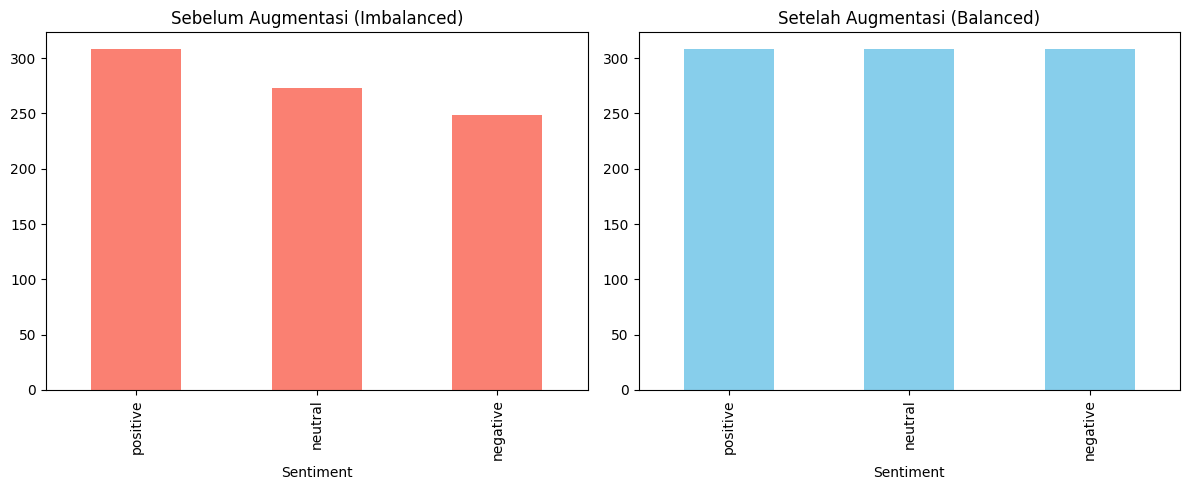

In [6]:
import matplotlib.pyplot as plt

# Data sebelum vs sesudah
before = df_hasil_aug[df_hasil_aug["is_augmented"] == False]["Sentiment"].value_counts()
after = df_hasil_aug["Sentiment"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

before.plot(kind="bar", ax=axes[0], title="Sebelum Augmentasi (Imbalanced)", color="salmon")
after.plot(kind="bar", ax=axes[1], title="Setelah Augmentasi (Balanced)", color="skyblue")

plt.tight_layout()
plt.show()

## TRACK B

In [12]:
import pandas as pd
import os

# Gunakan path relatif ke file kiriman temanmu
file_path_b = "train_balanced_flant5_track_b.csv"

if os.path.exists(file_path_b):
    df_hasil_aug_b = pd.read_csv(file_path_b)
    print("✅ Berhasil memuat data Track B.")
    
    # Filter data yang merupakan hasil augmentasi
    aug_only_b = df_hasil_aug_b[df_hasil_aug_b["is_augmented"] == True].copy()
    
    print(f"Data Asli Track B: {len(df_hasil_aug_b[df_hasil_aug_b['is_augmented'] == False])}")
    print(f"Data Augmentasi Track B: {len(aug_only_b)}")
    
    # Cek kolom yang digunakan (text_bert)
    print("\nContoh teks augmentasi Track B:")
    print(aug_only_b[['text_bert', 'Sentiment']].head(3))
else:
    print("❌ File Track B tidak ditemukan!")

✅ Berhasil memuat data Track B.
Data Asli Track B: 830
Data Augmentasi Track B: 94

Contoh teks augmentasi Track B:
                                           text_bert Sentiment
1  – adalah semamumkan lihat semamumkan bahwa lem...   neutral
3  The LPDP ini mengatakan bahwa belarang adang m...   neutral
9  JAKARTA, KOMPAS.com- Direktur Jenderal Adminit...  negative


### 1. Relevansi Kategori (Label Consistency)

In [13]:
from transformers import pipeline
from sklearn.metrics import accuracy_score

# Inisialisasi model hakim (jika belum di-load di segmen Track A)
classifier = pipeline("text-classification", model="w11wo/indonesian-roberta-base-sentiment-classifier")

# Ambil teks augmentasi dari kolom text_bert
aug_texts_b = aug_only_b["text_bert"].astype(str).tolist()
preds_b = classifier(aug_texts_b)

# Mapping hasil
predicted_labels_b = [p["label"].lower() for p in preds_b]
actual_labels_b = aug_only_b["Sentiment"].str.lower().tolist()

consistency_b = accuracy_score(actual_labels_b, predicted_labels_b)
print(f"Label Consistency Rate (Track B): {consistency_b:.2%}")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5991.01it/s]


Label Consistency Rate (Track B): 42.55%


### 2. Keberagaman Teks (Lexical Diversity)

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Ambil teks asli dan teks augmentasi dari track B
orig_texts_b = df_hasil_aug_b[df_hasil_aug_b["is_augmented"] == False]["text_bert"].astype(str).tolist()
aug_texts_b = aug_only_b["text_bert"].astype(str).tolist()

vectorizer_b = TfidfVectorizer()
all_vecs_b = vectorizer_b.fit_transform(orig_texts_b + aug_texts_b)

orig_vecs_b = all_vecs_b[:len(orig_texts_b)]
aug_vecs_b  = all_vecs_b[len(orig_texts_b):]

# Hitung kemiripan maksimal teks augmentasi terhadap teks asli
sim_scores_b = cosine_similarity(aug_vecs_b, orig_vecs_b)
avg_max_sim_b = np.mean(sim_scores_b.max(axis=1)) 

print(f"Rata-rata Kemiripan / Max Cosine Similarity (Track B): {avg_max_sim_b:.4f}")
# Catatan: Semakin rendah skor ini, semakin beragam teks yang dihasilkan.

Rata-rata Kemiripan / Max Cosine Similarity (Track B): 0.2181


### 3. Fluency (Cek Manual)

In [15]:
# Mengambil sampel acak untuk inspeksi kualitas bahasa pada format BERT
sample_eval_b = aug_only_b.sample(5)[["text_bert", "Sentiment"]]
print("Sampel teks untuk pengecekan kelancaran bahasa (Track B):")
print(sample_eval_b)

Sampel teks untuk pengecekan kelancaran bahasa (Track B):
                                             text_bert Sentiment
255  Agungkapkan pengalangan kode sakit resmi yang ...   neutral
28   (SP) 'We are very excited for the event. It is...   neutral
220  Kompas.tv - 20 Februari 2026, 21:49 WIB Soak K...  negative
158  Isu hanya mengadilan pembarkan kebunuh, yang s...  negative
373  Penerima beasiswa Perang-sosialita (LPDP) inis...   neutral


### 4. Distribusi Keseimbangan

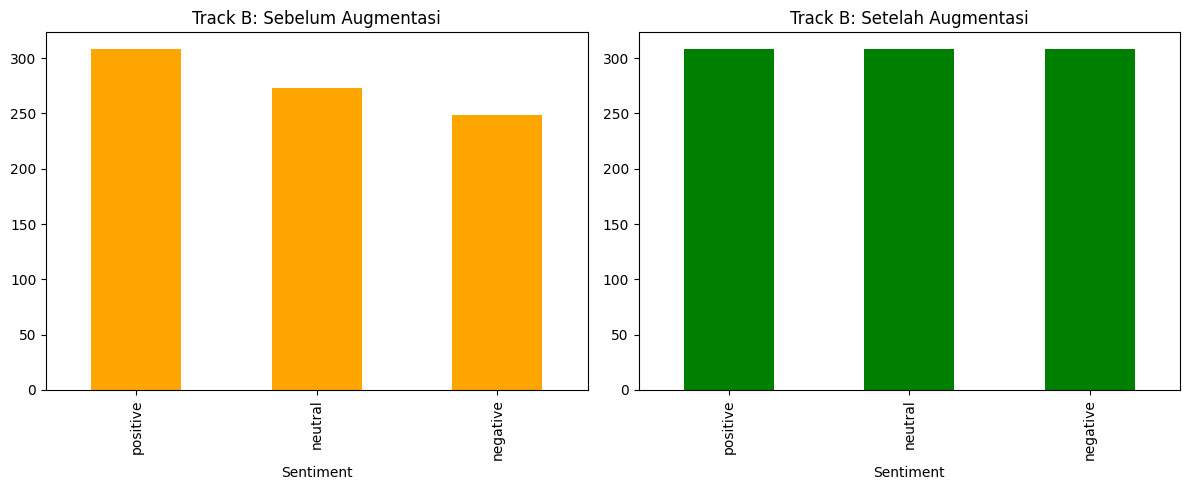

In [16]:
import matplotlib.pyplot as plt

# Hitung jumlah data sebelum dan sesudah augmentasi pada Track B
before_b = df_hasil_aug_b[df_hasil_aug_b["is_augmented"] == False]["Sentiment"].value_counts()
after_b = df_hasil_aug_b["Sentiment"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

before_b.plot(kind="bar", ax=axes[0], title="Track B: Sebelum Augmentasi", color="orange")
after_b.plot(kind="bar", ax=axes[1], title="Track B: Setelah Augmentasi", color="green")

plt.tight_layout()
plt.show()

## SUMMARY

/var/folders/wy/pyy9phgx4kngk0b6dmzdhvdh0000gn/T/ipykernel_45174/922506319.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Track A", "Track B"], y=[consistency, consistency_b], ax=ax[0], palette="viridis")
/var/folders/wy/pyy9phgx4kngk0b6dmzdhvdh0000gn/T/ipykernel_45174/922506319.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Track A", "Track B"], y=[avg_max_sim, avg_max_sim_b], ax=ax[1], palette="magma")


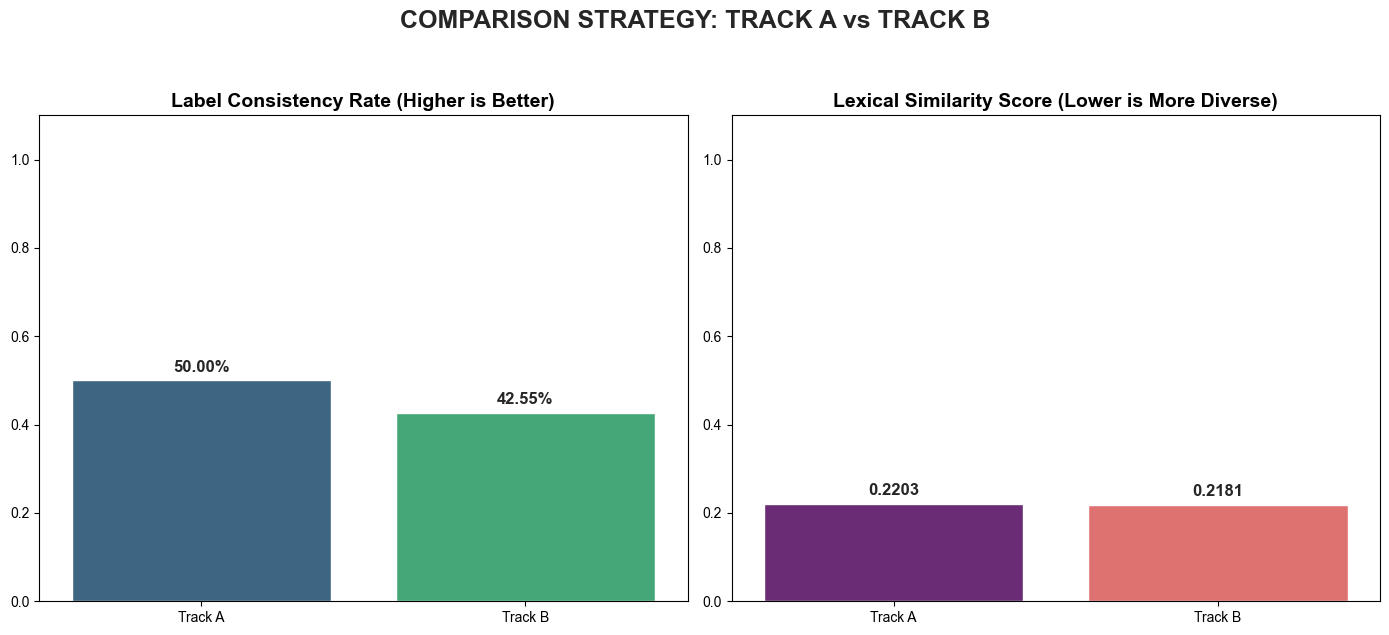


             DETAILED QUALITY COMPARISON TABLE


,Metric,Track A (Clean),Track B (BERT)
0,Label Consistency,0.5000,0.4255
1,Lexical Diversity,0.2203,0.2181



💡 SUMMARY INSIGHTS:
📌 Kualitas Semantik: Track A lebih unggul dalam mempertahankan makna asli teks.
📌 Keberagaman Kalimat: Track B menghasilkan variasi kata yang lebih kaya.
📌 Rekomendasi: Gunakan Track A sebagai dataset utama untuk training model.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menyiapkan Data Ringkasan
metrics = ["Label Consistency", "Lexical Diversity"]
track_a_scores = [consistency, avg_max_sim]
track_b_scores = [consistency_b, avg_max_sim_b]

summary_df = pd.DataFrame({
    "Metric": metrics,
    "Track A (Clean)": track_a_scores,
    "Track B (BERT)": track_b_scores
})

# 2. Visualisasi dengan Grouped Bar Chart
# Kita akan membuat 2 subplots untuk perbandingan yang adil
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.set_style("whitegrid")

# Plot 1: Label Consistency (Semakin TINGGI semakin bagus)
x = np.arange(len(metrics))
sns.barplot(x=["Track A", "Track B"], y=[consistency, consistency_b], ax=ax[0], palette="viridis")
ax[0].set_title("Label Consistency Rate (Higher is Better)", fontsize=14, fontweight='bold')
ax[0].set_ylim(0, 1.1)
for i, v in enumerate([consistency, consistency_b]):
    ax[0].text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold', fontsize=12)

# Plot 2: Lexical Diversity (Semakin RENDAH semakin bagus/beragam)
sns.barplot(x=["Track A", "Track B"], y=[avg_max_sim, avg_max_sim_b], ax=ax[1], palette="magma")
ax[1].set_title("Lexical Similarity Score (Lower is More Diverse)", fontsize=14, fontweight='bold')
ax[1].set_ylim(0, 1.1)
for i, v in enumerate([avg_max_sim, avg_max_sim_b]):
    ax[1].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', fontsize=12)

plt.suptitle("COMPARISON STRATEGY: TRACK A vs TRACK B", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# 3. Tabel Presentatif (Styled DataFrame)
print("\n" + "="*60)
print("             DETAILED QUALITY COMPARISON TABLE")
print("="*60)

def highlight_best(s):
    '''Highlight skor terbaik di setiap baris'''
    if s.name == "Label Consistency":
        is_max = s == s.max()
        return ['background-color: #d4edda' if v else '' for v in is_max]
    else: # Untuk Similarity, semakin kecil (min) semakin bagus
        is_min = s == s.min()
        return ['background-color: #d4edda' if v else '' for v in is_min]

# Menampilkan tabel dengan formatting persentase dan desimal
styled_summary = summary_df.style.format({
    "Track A (Clean)": "{:.4f}",
    "Track B (BERT)": "{:.4f}"
}).set_properties(**{'text-align': 'center', 'font-size': '12pt'})\
  .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f4f4f4'), ('font-weight', 'bold')]}])

display(styled_summary)

# 4. Insight Analisis untuk Laporan
print("\n" + "💡 SUMMARY INSIGHTS:")
best_label = "Track A" if consistency > consistency_b else "Track B"
best_div = "Track A" if avg_max_sim < avg_max_sim_b else "Track B"

print(f"📌 Kualitas Semantik: {best_label} lebih unggul dalam mempertahankan makna asli teks.")
print(f"📌 Keberagaman Kalimat: {best_div} menghasilkan variasi kata yang lebih kaya.")
print(f"📌 Rekomendasi: Gunakan {best_label} sebagai dataset utama untuk training model.")